In [1]:
%pip install timesfm[torch]

Note: you may need to restart the kernel to use updated packages.


In [6]:
import sherpa_utils
import torch
import numpy as np
import timesfm

DATASET_DIR = "../../../../../datasets"

In [9]:
gcp_df = sherpa_utils.sherpa_preprocess(f"{DATASET_DIR}/gcpDataset.csv")
gcp_cpu = sherpa_utils.sherpa_get_feature(context_df=gcp_df, resource_id="806067928863076857", metricName="compute.googleapis.com/instance/cpu/utilization")["target"].to_numpy(dtype=np.float32)
print(gcp_cpu)

[0.31845224 0.26501036 0.09732573 ... 0.11409411 0.12198702 0.12333165]


In [11]:
torch.set_float32_matmul_precision("high")

device = "cuda" if torch.cuda.is_available() else "cpu"

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch",
    torch_compile=True,
    device=device,
)

model.compile(
    timesfm.ForecastConfig(
        max_context=8192,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

W0710 13:54:43.883000 802758 torch/_dynamo/variables/tensor.py:1612] [0/0] Graph break from `Tensor.item()`, consider setting:
W0710 13:54:43.883000 802758 torch/_dynamo/variables/tensor.py:1612] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0710 13:54:43.883000 802758 torch/_dynamo/variables/tensor.py:1612] [0/0] or:
W0710 13:54:43.883000 802758 torch/_dynamo/variables/tensor.py:1612] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0710 13:54:43.883000 802758 torch/_dynamo/variables/tensor.py:1612] [0/0] to include these operations in the captured graph.
W0710 13:54:43.883000 802758 torch/_dynamo/variables/tensor.py:1612] [0/0] 
W0710 13:54:43.883000 802758 torch/_dynamo/variables/tensor.py:1612] [0/0] Graph break: from user code at:
W0710 13:54:43.883000 802758 torch/_dynamo/variables/tensor.py:1612] [0/0]   File "/home/cloudsherpa-collab/venvs/cloudsherpa/lib/python3.10/site-packages/timesfm/timesfm_2p5/timesfm_2p5_torch.py", line 101, in forward
W0710 13:54:43.8

(1, 12, 10)

In [13]:
point_forecast, quantile_forecast = model.forecast(
    horizon=12,
    inputs=[gcp_cpu]
)
point_forecast.shape  # (2, 12)



[[0.1174721  0.11519113 0.1142582  0.11576319 0.11406238 0.11381346
  0.11370786 0.1150222  0.11370538 0.11375282 0.11423969 0.11640451]]


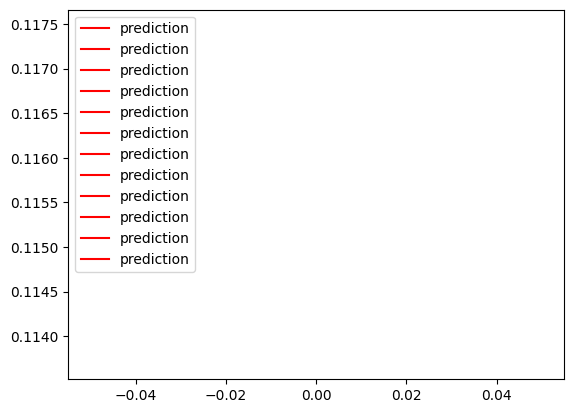

In [17]:
from matplotlib import pyplot

# Construct test evaluation, readd timestamps

pyplot.plot(point_forecast[:], color='red', label='prediction')
# pyplot.plot(pred_df['predictions'], color='blue', label='actual')
pyplot.legend(loc="upper left")
pyplot.show()